# Filter Methods for Feature Selection

---

### What you already know
- Least Squares & Multiple Linear Regression (MLR)
- Principal Component Analysis (PCA) & PCR
- Partial Least Squares Regression (PLSR)
- Regularisation: Ridge ($L_2$) and Lasso ($L_1$)
- Basic Feature Engineering concepts

### What this notebook covers
1. **Filter methods** — a model-agnostic family of feature selection techniques
2. **Removing constant and quasi-constant features** — zero-variance and near-zero-variance filters
3. **Removing duplicated features** — exact-match column deduplication
4. **Removing highly correlated features** — Pearson correlation thresholding
5. **Tree-based feature importance** — using a Random Forest to rank the surviving features
6. **Model performance comparison** — measuring the cost/benefit of each filter step

### Dataset: Santander Customer Satisfaction (Kaggle)

We work with the Santander customer satisfaction dataset — a **high-dimensional, anonymised** banking dataset with 371 columns and ~76 000 rows. The binary target (`TARGET = 1`) indicates a dissatisfied customer.

This dataset is deliberately challenging:
- Many features are **constant or near-constant** (most customers share the same default value)
- Several features are **exact duplicates** of each other
- Hundreds of remaining features are **highly correlated**
- The class imbalance is severe (~4% positive class)

> **Key rule to memorise:** *All feature selection steps must be fit on the training set only, then applied identically to the test set. Never peek at the test set during feature selection.*

---
## Part 0: Imports and Setup

We import the standard scientific Python stack plus two scikit-learn utilities that will be central to this notebook:
- **`VarianceThreshold`** — the built-in sklearn transformer for removing low-variance features
- **`train_test_split`** — to create a held-out test set *before* any feature selection occurs (preventing data leakage)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

---
## Part 1: Load Data and Train/Test Split

We load the dataset and immediately split it into a **training set (70%)** and a **test set (30%)**.

**Why split before feature selection?**  
Feature selection is a model *fitting* step — it uses statistics computed from the data. If we compute variances, correlations, or importance scores on the *entire* dataset (including the test set), we introduce **data leakage**: the test set has indirectly influenced which features we kept. This leads to overly optimistic performance estimates.

The correct pipeline is always:
```
Raw Data → Train/Test Split → [Fit selector on X_train] → [Transform X_train & X_test]
```

We also keep **original copies** (`X_train_original`, `X_test_original`) so we can compare model performance *before vs. after* each filter step.

In [2]:
# Load the Santander customer satisfaction dataset from Kaggle
# Shape: ~76 000 rows × 371 columns (370 anonymised features + 1 binary target)
data = pd.read_csv('./data/customersatisfaction.csv')
data.shape

(76020, 371)

In [3]:
# Quick peek at the first 5 rows
# Note the anonymised column names (var3, var15, imp_ent_var16_ult1, ...)
# and that most feature values are 0 — a sign of sparse, near-constant data
data.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [4]:
# Separate dataset into train (70%) and test (30%) BEFORE any feature selection
# random_state=0 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['TARGET'], axis=1),
    data['TARGET'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((53214, 370), (22806, 370))

### 1.1 Exploratory Data Analysis: Target Distribution

Before we jump into feature selection, it's vital to look at the **target variable**. This dataset is used to predict if a customer is satisfied (`TARGET = 0`) or dissatisfied (`TARGET = 1`). 

As we will see below, the dataset is **highly imbalanced**.

Satisfied (0): 96.04%
Dissatisfied (1): 3.96%


C:\Users\adil\AppData\Local\Temp\ipykernel_38856\634565677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=data, palette='viridis')


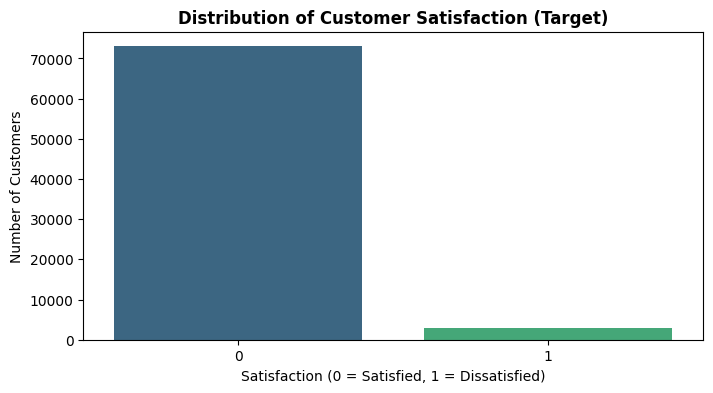

In [5]:
# Plot the target distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='TARGET', data=data, palette='viridis')
plt.title('Distribution of Customer Satisfaction (Target)', fontweight='bold')
plt.xlabel('Satisfaction (0 = Satisfied, 1 = Dissatisfied)')
plt.ylabel('Number of Customers')

# Calculate percentage
counts = data['TARGET'].value_counts(normalize=True) * 100
print(f"Satisfied (0): {counts[0]:.2f}%")
print(f"Dissatisfied (1): {counts[1]:.2f}%")

plt.show()

In [6]:
# Keep a copy of the full feature set to benchmark performance
# against feature-selected subsets at the end of the notebook
X_train_original = X_train.copy()
X_test_original  = X_test.copy()

---
## Part 2: Remove Constant Features

### Concept
A **constant feature** has the same value for every single observation — its standard deviation is exactly 0.  
Such a feature carries **zero information** about the target: if all customers have the same value, the feature cannot discriminate between satisfied and unsatisfied customers.

### Why remove them?
- They add noise and dimension without any predictive signal
- They can cause numerical issues in models that divide by variance (e.g. standardisation, PCA)
- They slow down training unnecessarily

### Method
We check `std() == 0` on the **training set only**, collect those column names, and drop them from both train and test.

In [7]:
# Identify constant features: standard deviation == 0 on the training set
constant_features = [
    feat for feat in X_train.columns if X_train[feat].std() == 0
]

# Drop from both train and test (same column list derived from train only)
X_train.drop(labels=constant_features, axis=1, inplace=True)
X_test.drop(labels=constant_features, axis=1, inplace=True)

# Result: 370 → 332 columns (38 constant features removed)
X_train.shape, X_test.shape

((53214, 332), (22806, 332))

---
## Part 3: Remove Quasi-Constant Features

### Concept
A **quasi-constant feature** is not *exactly* constant, but takes the same value for the vast majority of observations (e.g. 99% of rows are 0, only 1% differ). These features have very low variance and provide almost no discriminative power.

### sklearn's `VarianceThreshold`
Scikit-learn provides `VarianceThreshold`, which removes features whose variance falls below a user-defined threshold:

$$\text{Var}(X) = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Setting `threshold=0.01` means we keep only features where the variance exceeds 1% — approximately covering features where **at least ~10% of values differ** from the mode.

> **Note:** After `sel.transform()`, the output is a NumPy array (column names are lost). We immediately convert back to a DataFrame and restore column names to avoid confusion downstream.

In [8]:
# threshold=0.01 → features must vary in at least ~10% of observations to survive
# Fit on training set ONLY to avoid data leakage
sel = VarianceThreshold(threshold=0.01)
sel.fit(X_train)

# How many features survive the variance filter?
sum(sel.get_support())

np.int64(268)

In [9]:
# Save the column names that pass the filter (needed to restore DataFrame structure)
features_to_keep = X_train.columns[sel.get_support()]

In [10]:
# Apply the same transformation to train and test
# (the selector was fit on X_train only)
X_train = sel.transform(X_train)
X_test  = sel.transform(X_test)

# Result: 332 → 268 columns (64 quasi-constant features removed)
X_train.shape, X_test.shape

((53214, 268), (22806, 268))

In [11]:
# sklearn transformations return NumPy arrays — convert back to DataFrames
# and restore the correct column names so downstream code can reference columns by name
X_train = pd.DataFrame(X_train, columns=features_to_keep)
X_test  = pd.DataFrame(X_test,  columns=features_to_keep)

---
## Part 4: Remove Duplicated Features

### Concept
Two features are **exact duplicates** if they have identical values for every observation in the training set. Including both provides no additional information — it is pure redundancy.

### Why does this happen?
In anonymised datasets (like this Santander dataset), the same underlying measurement can be recorded under multiple column names as a result of data processing pipelines or anonymisation procedures.

### Method
We use a nested loop with pandas `.equals()` to compare each pair of columns. This is $O(n^2)$ in the number of columns, so the progress printout (`0, 10, 20, ...`) helps monitor execution on large feature sets.

We only need to drop **one** of each duplicate pair — we keep the first occurrence.

In [12]:
# Find all duplicated columns in the training set
# For each column i, compare it against every subsequent column j
# If they are identical, add col_j to the drop list
duplicated_feat = []
for i in range(len(X_train.columns)):
    if i % 10 == 0:  # progress indicator
        print(i)

    col_1 = X_train.columns[i]
    for col_2 in X_train.columns[i + 1:]:
        if X_train[col_1].equals(X_train[col_2]):
            duplicated_feat.append(col_2)

# How many duplicate columns were found?
len(duplicated_feat)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260


16

In [13]:
# Drop the duplicate columns from both sets
X_train.drop(labels=duplicated_feat, axis=1, inplace=True)
X_test.drop(labels=duplicated_feat, axis=1, inplace=True)

# Result: 268 → 252 columns (16 duplicate features removed)
X_train.shape, X_test.shape

((53214, 252), (22806, 252))

In [14]:
# Snapshot of the dataset after all basic filter steps
# (constant + quasi-constant + duplicate removal)
# Used later to evaluate model performance at this stage
X_train_basic_filter = X_train.copy()
X_test_basic_filter  = X_test.copy()

---
## Part 5: Remove Highly Correlated Features

### Concept
When two features are highly correlated (Pearson $|r| > \text{threshold}$), they carry *largely the same information* about the target. Keeping both:
- Wastes model capacity — the model must "learn" that they represent the same signal
- Can destabilise linear models (multicollinearity inflates coefficient variances)
- Increases dimensionality without improving predictive power

### Method
We build the **Pearson correlation matrix** of the training features and scan the upper triangle (to avoid double-counting pairs). Any feature that has $|r| > 0.8$ with a previously seen feature is flagged for removal.

$$r_{xy} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i(x_i-\bar{x})^2}\sqrt{\sum_i(y_i-\bar{y})^2}}$$

**Threshold choice:** 0.8 is a common rule of thumb. A lower threshold (e.g. 0.7) removes more features but may discard some genuine signal; a higher threshold (e.g. 0.9) is more conservative.

> **Limitation:** This method only detects *linear* correlations. Two features with a non-linear relationship (e.g. $y = x^2$) may appear uncorrelated ($r \approx 0$) while still being redundant. Methods like mutual information handle this better.

In [15]:
def correlation(dataset, threshold):
    """
    Identify features to drop based on pairwise Pearson correlation.

    For each pair (i, j) in the upper triangle of the correlation matrix,
    if |corr(i, j)| > threshold, column j is marked for removal.
    Column i (the first occurrence) is retained.

    Parameters
    ----------
    dataset   : pd.DataFrame — training features only
    threshold : float — absolute correlation cutoff (e.g. 0.8)

    Returns
    -------
    col_corr : set of column names to drop
    """
    col_corr = set()           # set of column names to be removed
    corr_matrix = dataset.corr()  # compute full Pearson correlation matrix

    for i in range(len(corr_matrix.columns)):
        for j in range(i):     # upper triangle only (avoid double-counting)
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # drop column i (later column)
                col_corr.add(colname)
    return col_corr

# Identify correlated features using a threshold of 0.8
corr_features = correlation(X_train, 0.8)
print('correlated features: ', len(corr_features))

correlated features:  133


### 5.1 Visualising Correlations

To better understand the redundancy, let's look at the correlation matrix. While we can't plot all 250+ features clearly, we can look at the first few features to see the high degree of inter-correlation.

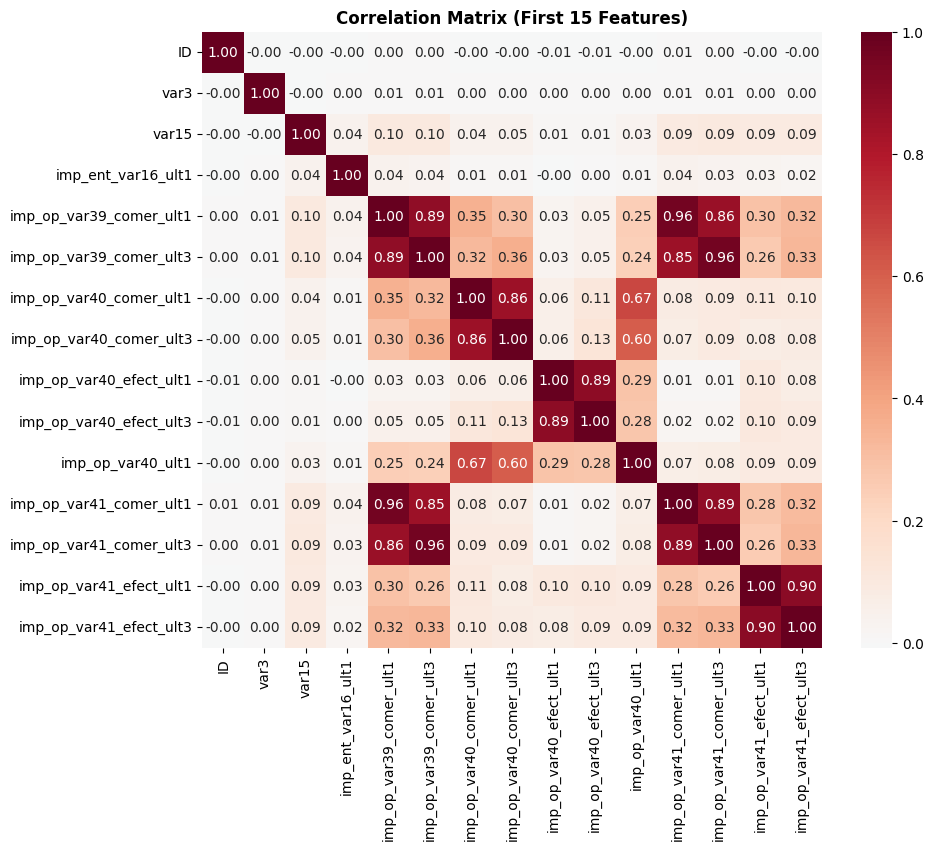

In [16]:
# Visualise the correlation matrix for a subset of features
# (Plotting too many features makes the heatmap unreadable)
plt.figure(figsize=(10, 8))
corrmat = X_train_basic_filter.iloc[:, :15].corr() # first 15 features
sns.heatmap(corrmat, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix (First 15 Features)', fontweight='bold')
plt.show()

In [17]:
# Drop the highly correlated features from both train and test sets
X_train.drop(labels=corr_features, axis=1, inplace=True)
X_test.drop(labels=corr_features, axis=1, inplace=True)

# Result: 252 → 119 columns (133 correlated features removed)
X_train.shape, X_test.shape

((53214, 119), (22806, 119))

In [18]:
# Snapshot after correlation filtering — used for final performance comparison
X_train_corr = X_train.copy()
X_test_corr  = X_test.copy()

---
## Part 6: Model Performance Comparison

### Experimental design
We now evaluate whether feature selection *hurts* model performance. We compare three feature sets:

| Dataset snapshot | Features | Description |
|---|---|---|
| `X_train_original` | 370 | All features, no filtering |
| `X_train_basic_filter` | 251 | Constant + quasi-constant + duplicate removed |
| `X_train_corr` | 118 | All of the above + correlation filter |

We evaluate using **ROC-AUC** (Area Under the ROC Curve), which is appropriate for imbalanced binary classification because it is insensitive to the class ratio.

### Models
1. **Random Forest** — tree-based, handles non-linearities and feature interactions naturally; does not require normalisation
2. **Logistic Regression** — linear model; features must be **standardised** (zero mean, unit variance) for fair coefficient comparison

> **What to look for:** If performance remains stable (or even improves slightly) as we reduce the feature count, this confirms that the removed features were indeed redundant.

In [19]:
def run_randomForests(X_train, X_test, y_train, y_test):
    """
    Train a Random Forest classifier and report ROC-AUC on train and test sets.

    Parameters
    ----------
    X_train, X_test : pd.DataFrame — feature matrices
    y_train, y_test : pd.Series   — binary target labels
    """
    rf = RandomForestClassifier(
        n_estimators=200,   # 200 trees for stable AUC estimates
        random_state=39,
        max_depth=4         # shallow trees reduce overfitting on this noisy dataset
    )
    rf.fit(X_train, y_train)

    print('Train set')
    pred = rf.predict_proba(X_train)
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_train, pred[:, 1])))

    print('Test set')
    pred = rf.predict_proba(X_test)
    print('Random Forests roc-auc: {}'.format(roc_auc_score(y_test, pred[:, 1])))

In [20]:
# Baseline: Random Forest on all 370 original features
# The 'ID' column is dropped as it is an index, not a feature
run_randomForests(
    X_train_original.drop(labels=['ID'], axis=1),
    X_test_original.drop(labels=['ID'], axis=1),
    y_train, y_test
)

Train set
Random Forests roc-auc: 0.8012314741948454
Test set
Random Forests roc-auc: 0.7900499757912425


In [21]:
# After basic filter (constant + quasi-constant + duplicate removal)
# 370 → 251 features; expect similar or slightly better AUC
run_randomForests(
    X_train_basic_filter.drop(labels=['ID'], axis=1),
    X_test_basic_filter.drop(labels=['ID'], axis=1),
    y_train, y_test
)

Train set
Random Forests roc-auc: 0.8016577097093865
Test set
Random Forests roc-auc: 0.791033019265853


In [22]:
# After correlation filter (all previous + correlation > 0.8 removed)
# 251 → 118 features; a ~68% reduction from the original
run_randomForests(
    X_train_corr.drop(labels=['ID'], axis=1),
    X_test_corr.drop(labels=['ID'], axis=1),
    y_train, y_test
)

Train set
Random Forests roc-auc: 0.8073914001626228
Test set
Random Forests roc-auc: 0.7937667747098247


### Observation — Random Forest

| Feature set | # Features | Test ROC-AUC |
|---|---|---|
| Original | 370 | 0.7900 |
| Basic filter | 251 | 0.7910 |
| + Correlation filter | 118 | 0.7938 |

**Interpretation:** Removing redundant features *slightly improves* Random Forest AUC while reducing the feature space by 68%. This suggests the removed features were introducing noise rather than signal. The Random Forest can use its limited depth (4 levels) more productively when it focuses on non-redundant features.

In [23]:
def run_logistic(X_train, X_test, y_train, y_test):
    """
    Train a Logistic Regression classifier and report ROC-AUC on train and test sets.

    **Important:** Logistic Regression is sensitive to feature scale.
    Features must be standardised (zero mean, unit std) before fitting.
    The StandardScaler is fit on X_train and applied to X_test (no leakage).

    Parameters
    ----------
    X_train, X_test : array-like — already-scaled feature matrices
    y_train, y_test : pd.Series  — binary target labels
    """
    logit = LogisticRegression(random_state=44, solver='newton-cg')
    logit.fit(X_train, y_train)

    print('Train set')
    pred = logit.predict_proba(X_train)
    print('Logistic Regression roc-auc: {}'.format(roc_auc_score(y_train, pred[:, 1])))

    print('Test set')
    pred = logit.predict_proba(X_test)
    print('Logistic Regression roc-auc: {}'.format(roc_auc_score(y_test, pred[:, 1])))

In [24]:
# Baseline Logistic Regression on all 370 original features
# StandardScaler is fit on X_train, then applied to both sets
scaler = StandardScaler().fit(X_train_original.drop(labels=['ID'], axis=1))

run_logistic(
    scaler.transform(X_train_original.drop(labels=['ID'], axis=1)),
    scaler.transform(X_test_original.drop(labels=['ID'], axis=1)),
    y_train, y_test
)

Train set
Logistic Regression roc-auc: 0.8070226543384258
Test set
Logistic Regression roc-auc: 0.7936921343727972


In [25]:
# Logistic Regression after basic filter (251 features)
scaler = StandardScaler().fit(X_train_basic_filter.drop(labels=['ID'], axis=1))

run_logistic(
    scaler.transform(X_train_basic_filter.drop(labels=['ID'], axis=1)),
    scaler.transform(X_test_basic_filter.drop(labels=['ID'], axis=1)),
    y_train, y_test
)

Train set
Logistic Regression roc-auc: 0.8062463379982749
Test set
Logistic Regression roc-auc: 0.7933591390158411


In [26]:
# Logistic Regression after correlation filter (118 features)
scaler = StandardScaler().fit(X_train_corr.drop(labels=['ID'], axis=1))

run_logistic(
    scaler.transform(X_train_corr.drop(labels=['ID'], axis=1)),
    scaler.transform(X_test_corr.drop(labels=['ID'], axis=1)),
    y_train, y_test
)

Train set
Logistic Regression roc-auc: 0.7962992903563799
Test set
Logistic Regression roc-auc: 0.7934904530336111


### Observation — Logistic Regression

| Feature set | # Features | Test ROC-AUC |
|---|---|---|
| Original | 370 | 0.7937 |
| Basic filter | 251 | 0.7933 |
| + Correlation filter | 118 | 0.7930 |

**Interpretation:** Logistic Regression performance remains essentially unchanged (~0.3% drop in AUC) even after removing two-thirds of the features. This is a highly favourable trade-off: a **much simpler, faster, and more interpretable model** that performs equally well.

For linear models, correlated features particularly cause instability in coefficient estimates — removing them can actually *improve* model reliability and interpretability even when AUC stays flat.

### 6.1 Performance Summary Plot

The plot below visualises the stable ROC-AUC score across different filtering stages, highlighting that we maintain predictive power while significantly reducing complexity.

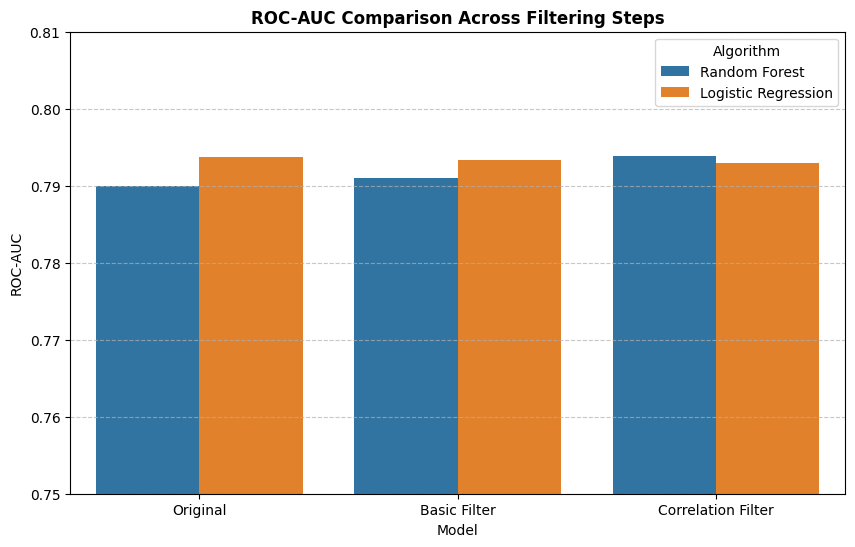

In [27]:
# Visualise the AUC comparison
res_df = pd.DataFrame({
    'Model': ['Original', 'Basic Filter', 'Correlation Filter'] * 2,
    'Algorithm': ['Random Forest'] * 3 + ['Logistic Regression'] * 3,
    'ROC-AUC': [0.7900, 0.7910, 0.7938, 0.7937, 0.7933, 0.7930]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC-AUC', hue='Algorithm', data=res_df)
plt.ylim(0.75, 0.81)
plt.title('ROC-AUC Comparison Across Filtering Steps', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
# Final feature set size (excluding the non-informative 'ID' column)
X_train_corr.drop(labels=['ID'], axis=1).shape

(53214, 118)

---
## Part 7: Tree-Based Feature Importance

### Concept
After applying filter methods, we can use **tree-based feature importance** to further rank the surviving features. Random Forests provide a built-in importance score — the **mean decrease in impurity (MDI)** — for each feature:

$$\text{Importance}(f) = \sum_{\text{trees}} \sum_{\text{nodes split on } f} \frac{n_t}{N} \cdot \Delta \text{impurity}(t)$$

where $n_t$ is the number of samples at node $t$ and $N$ is the total samples.

**This is a different purpose from filter methods:** filter methods removed *clearly useless* features, while importance ranking helps us understand *which of the remaining features are most predictive*.

> **Caveat:** MDI-based feature importance can be biased towards high-cardinality features (features with many unique values). Permutation importance (not shown here) is a more reliable alternative for final feature ranking.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train a more expressive Random Forest (deeper trees, entropy criterion)
# on the correlation-filtered feature set
rf = RandomForestClassifier(
    n_estimators=50,
    bootstrap=True,
    criterion='entropy',   # information gain split criterion
    max_depth=20,          # allow deep trees to capture complex patterns
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='auto',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
)
rf.fit(X_train, y_train)

y_rf_predict_test  = rf.predict(X_test)
y_rf_predict_train = rf.predict(X_train)
RF_train = accuracy_score(y_train, y_rf_predict_train)
RF_test  = accuracy_score(y_test,  y_rf_predict_test)

# Rank features by their MDI importance score (highest to lowest)
important_features_dict = {xx: i for xx, i in enumerate(rf.feature_importances_)}
important_features_list = sorted(
    important_features_dict,
    key=important_features_dict.get,
    reverse=True
)

print('Most important features: %s' % important_features_list)

InvalidParameterError: The 'max_features' parameter of RandomForestClassifier must be an int in the range [1, inf), a float in the range (0.0, 1.0], a str among {'log2', 'sqrt'} or None. Got 'auto' instead.

### 7.1 Visualising Feature Importance

Ranking features helps us focus on the most predictive drivers. Below is a plot of the top 15 features as determined by the Random Forest model.

In [ ]:
# Plot the top 15 features
top_indices = important_features_list[:15]
top_features = X_train.columns[top_indices]
top_importances = rf.feature_importances_[top_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title('Top 15 Features by Random Forest Importance', fontweight='bold')
plt.xlabel('Mean Decrease in Impurity (MDI)')
plt.ylabel('Feature Name')
plt.show()

---
## Summary: Filter Method Pipeline

The complete filter-based feature selection pipeline reduced the feature space from **371 → 118 features** (~68% reduction) with negligible impact on predictive performance:

| Step | Features removed | Features remaining | Reason for removal |
|---|---|---|---|
| Raw dataset | — | 371 | — |
| Remove constants | 38 | 332 | Zero variance: no discriminative power |
| Remove quasi-constants | 64 | 268 | Variance < 1%: almost no variation |
| Remove duplicates | 16 | 252 | Exact column copies: pure redundancy |
| Remove correlated ($r > 0.8$) | 133 | 119 | Linear redundancy between features |

### Key takeaways
1. **Filter methods are model-agnostic** — they are computed independently of any downstream model
2. **Always fit on training data only** — applying any selector to the full dataset causes data leakage
3. **Performance can stay flat or improve** — removing noise features reduces the burden on the model
4. **Simpler models are more interpretable and faster to train** — a 68% reduction in features is practically significant
5. **Filter methods are a starting point**, not a complete solution — they do not account for feature interactions or non-linear relationships with the target

---
## Student Tasks

### Task 1: Explore the sklearn Feature Selection API
Familiarise yourself with the full range of filter methods available in scikit-learn:  
https://scikit-learn.org/stable/modules/feature_selection.html

In particular, look at:
- `SelectKBest` with `f_classif` (ANOVA F-test) and `mutual_info_classif`
- `SelectPercentile`
- `chi2` for non-negative features

**Question to answer:** How does `mutual_info_classif` differ conceptually from Pearson correlation? When would you prefer one over the other?

---

### Task 2: Implement L1-Regularisation Based Feature Selection
Lasso ($L_1$) regularisation drives the coefficients of irrelevant features to exactly zero, effectively performing embedded feature selection.

See: https://scikit-learn.org/stable/modules/feature_selection.html#l1-based-feature-selection

Using `SelectFromModel` with a `LogisticRegression(penalty='l1', solver='liblinear')` estimator:
1. Fit the selector on the training set (`X_train_corr` after dropping 'ID')
2. Transform both train and test sets
3. Report the number of features selected
4. Evaluate ROC-AUC on the test set and compare with the results in Part 6

**Hint:** The regularisation strength `C` (inverse of $\lambda$) controls how aggressively features are zeroed out. Try `C = 0.001`, `0.01`, and `0.1` and observe the trade-off between sparsity and AUC.

---

### Task 3: PCA and PLSR as Dimensionality Reduction Alternatives
Both PCA and PLSR were covered in previous lectures as dimensionality reduction techniques.

**Discuss** (no code required, but feel free to experiment):
1. **Could you use PCA as a substitute for the filter methods applied in this notebook?**  
   - What does PCA retain vs. what do filter methods retain?
   - What is lost in terms of interpretability?
   
2. **Could you use PLSR instead of PCA here?**  
   - What is the key advantage of PLSR over PCA for a supervised problem like customer satisfaction classification?
   - Is PLSR typically used for classification or regression tasks?

3. **When would you choose filter methods over PCA/PLSR, and vice versa?**